TRAIN ACCURACY: 0.872
TEST ACCURACY : 0.90625

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.84      1.00      0.91        16

    accuracy                           0.91        32
   macro avg       0.92      0.91      0.91        32
weighted avg       0.92      0.91      0.91        32


Matrice de confusion :
[[13  3]
 [ 0 16]]


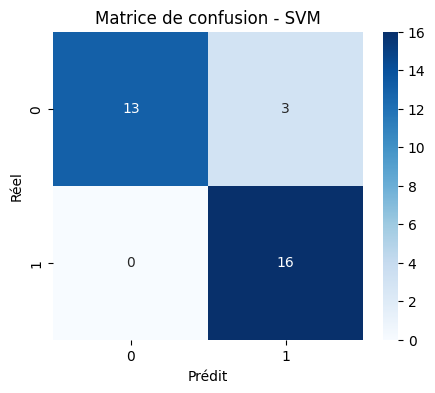

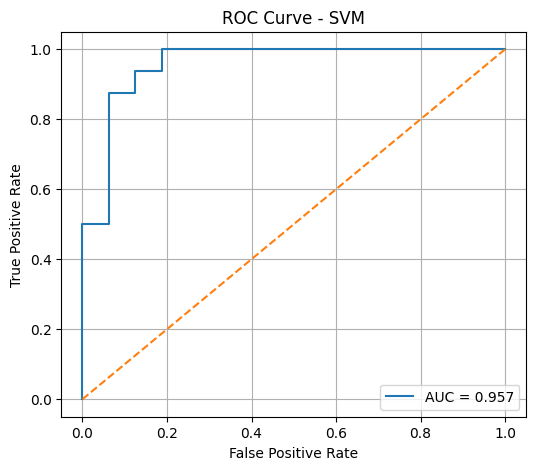

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ======================
# 1. LOAD DATA
# ======================
df = pd.read_excel("donnees_pretraitees.xlsx")

# ======================
# 2. TARGET CLEAN
# ======================
df["diagnosis"] = df["diagnosis"].astype(str).str.strip().str.lower()
df = df[df["diagnosis"].isin(["pe", "non-pe"])]

y = df["diagnosis"].map({"pe": 1, "non-pe": 0})

# ======================
# 3. FEATURES
# ======================
X = df.drop(columns=["diagnosis", "disease_status", "gsm", "title"], errors="ignore")

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean(numeric_only=True))

# ======================
# 4. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================
# 5. SCALING
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================
# 6. MODEL SVM
# ======================
model = SVC(
    kernel="rbf",
    C=0.2,
    gamma="scale",
    class_weight="balanced",
    probability=True
)

model.fit(X_train, y_train)

# ======================
# 7. PREDICTIONS
# ======================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

# ======================
# 8. ACCURACY
# ======================
print("TRAIN ACCURACY:", accuracy_score(y_train, y_train_pred))
print("TEST ACCURACY :", accuracy_score(y_test, y_test_pred))

# ======================
# 9. CLASSIFICATION REPORT
# ======================
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# ======================
# 10. MATRICE DE CONFUSION
# ======================
cm = confusion_matrix(y_test, y_test_pred)

print("\nMatrice de confusion :")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - SVM")
plt.show()

# ======================
# 11. ROC CURVE
# ======================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid()
plt.show()